# <span style="color: Lightblue;">Contexte

<h2>This notebook is dedicated to understanding the subject and exploring the data.<h2/>

<h3>"The dataset includes 174 metrics and 297,099 rows of data of tropical storms in the United States
collected from 1980 onwards. The data is raw, imperfect, and has not been cleaned or preprocessed."<h3/>

<h3>"Information about the dataset attributes can be found in the IBTRACS_variable_documentation file. Using the provided dataset, you are asked to train a model to predict the severity of a tropical cyclone based on geographical input data."<h3/>

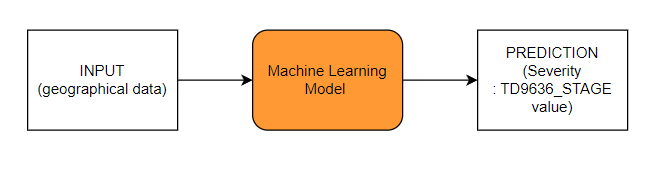

We want to predict the 145th column of the dataset 

# <span style="color: orange;">1. Data Loading

In [8]:
#Import libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

In [9]:
#Import and read the csv file. Display the 5 first rows


# Read the dataset starting from the third row and set the column names
df = pd.read_csv('ibtracs.csv', skiprows=[1], na_values=['', ' ', 'NA'])

#df = pd.read_csv("ibtracs.csv", na_values=['', ' ', 'NA'])
df.head(5)




C:\Users\shikh\AppData\Local\Temp\ipykernel_30876\2327177049.py:5: DtypeWarning: Columns (12,21,61,66,77,139,154) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('ibtracs.csv', skiprows=[1], na_values=['', ' ', 'NA'])


,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,...,BOM_GUST_PER,REUNION_GUST,REUNION_GUST_PER,USA_SEAHGT,USA_SEARAD_NE,USA_SEARAD_SE,USA_SEARAD_SW,USA_SEARAD_NW,STORM_SPEED,STORM_DIR
0,1980001S13173,1980,1,SP,MM,PENI,1980-01-01 00:00:00,TS,-12.5,172.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,350.0
1,1980001S13173,1980,1,SP,MM,PENI,1980-01-01 03:00:00,TS,-12.2,172.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,350.0
2,1980001S13173,1980,1,SP,MM,PENI,1980-01-01 06:00:00,TS,-11.9,172.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,360.0
3,1980001S13173,1980,1,SP,MM,PENI,1980-01-01 09:00:00,TS,-11.7,172.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,10.0
4,1980001S13173,1980,1,SP,MM,PENI,1980-01-01 12:00:00,TS,-11.5,172.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,20.0


# <span style="color: orange;">2. Data Cleaning

## 2.1 Checking for columns with extreme missing values

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297098 entries, 0 to 297097
Columns: 174 entries, SID to STORM_DIR
dtypes: float64(152), int64(4), object(18)
memory usage: 394.4+ MB


In [12]:
# On repère les colonnes qui vont nous poser problèmes, ici les colonnes avec de NaN
# We identify the columns that are going to cause us problems, here the columns with NaN

df.isna().sum()

SID                      0
SEASON                   0
NUMBER                   0
BASIN                40518
SUBBASIN             32646
NAME                     0
ISO_TIME                 0
NATURE                   0
LAT                      0
LON                      0
WMO_WIND            184425
WMO_PRES            176033
WMO_AGENCY          166481
TRACK_TYPE               0
DIST2LAND                0
LANDFALL              4767
IFLAG                    0
USA_AGENCY          169765
USA_ATCF_ID          43214
USA_LAT              45024
USA_LON              45024
USA_RECORD          296370
USA_STATUS          128610
USA_WIND             45997
USA_PRES            146629
USA_SSHS                 0
USA_R34_NE          227229
USA_R34_SE          227240
USA_R34_SW          227284
USA_R34_NW          227254
USA_R50_NE          260957
USA_R50_SE          260991
USA_R50_SW          261089
USA_R50_NW          261011
USA_R64_NE          274789
USA_R64_SE          274826
USA_R64_SW          274875
U

In [13]:
# Calculate the percentage of missing values in each column
missing_percentage = df.isna().mean() * 100

# Display the column names and their corresponding missing value percentages
missing_percentage_df = pd.DataFrame(missing_percentage, columns=['Missing Percentage'])

pd.set_option('display.max_rows', None)
print(missing_percentage_df)

                  Missing Percentage
SID                         0.000000
SEASON                      0.000000
NUMBER                      0.000000
BASIN                      13.637924
SUBBASIN                   10.988293
NAME                        0.000000
ISO_TIME                    0.000000
NATURE                      0.000000
LAT                         0.000000
LON                         0.000000
WMO_WIND                   62.075477
WMO_PRES                   59.250820
WMO_AGENCY                 56.035719
TRACK_TYPE                  0.000000
DIST2LAND                   0.000000
LANDFALL                    1.604521
IFLAG                       0.000000
USA_AGENCY                 57.141078
USA_ATCF_ID                14.545369
USA_LAT                    15.154595
USA_LON                    15.154595
USA_RECORD                 99.754963
USA_STATUS                 43.288746
USA_WIND                   15.482097
USA_PRES                   49.353749
USA_SSHS                    0.000000
U

<span style="color: Orange;">
Findings :- More than 85% of columns are as good as empty
</span>

## 2.2 Handling the almost empty columns

In [14]:
# Calculate the percentage of missing values in each column
missing_percentage = df.isna().mean() * 100

# Filter out columns with more than 30% missing values
columns_to_drop = missing_percentage[missing_percentage > 20].index

# Drop the columns from the dataframe
df = df.drop(columns=columns_to_drop)


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297098 entries, 0 to 297097
Data columns (total 21 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   SID          297098 non-null  object 
 1   SEASON       297098 non-null  int64  
 2   NUMBER       297098 non-null  int64  
 3   BASIN        256580 non-null  object 
 4   SUBBASIN     264452 non-null  object 
 5   NAME         297098 non-null  object 
 6   ISO_TIME     297098 non-null  object 
 7   NATURE       297098 non-null  object 
 8   LAT          297098 non-null  float64
 9   LON          297098 non-null  float64
 10  TRACK_TYPE   297098 non-null  object 
 11  DIST2LAND    297098 non-null  int64  
 12  LANDFALL     292331 non-null  float64
 13  IFLAG        297098 non-null  object 
 14  USA_ATCF_ID  253884 non-null  object 
 15  USA_LAT      252074 non-null  float64
 16  USA_LON      252074 non-null  float64
 17  USA_WIND     251101 non-null  float64
 18  USA_SSHS     297098 non-

In [16]:
# Calculate the number of missing values and the percentage of missing values in each column
missing_counts = df.isna().sum()
missing_percentage = df.isna().mean() * 100

# Combine the results into a single DataFrame
missing_data = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage': missing_percentage
})


# Print the DataFrame
print(missing_data)

             Missing Count  Missing Percentage
SID                      0            0.000000
SEASON                   0            0.000000
NUMBER                   0            0.000000
BASIN                40518           13.637924
SUBBASIN             32646           10.988293
NAME                     0            0.000000
ISO_TIME                 0            0.000000
NATURE                   0            0.000000
LAT                      0            0.000000
LON                      0            0.000000
TRACK_TYPE               0            0.000000
DIST2LAND                0            0.000000
LANDFALL              4767            1.604521
IFLAG                    0            0.000000
USA_ATCF_ID          43214           14.545369
USA_LAT              45024           15.154595
USA_LON              45024           15.154595
USA_WIND             45997           15.482097
USA_SSHS                 0            0.000000
STORM_SPEED              8            0.002693
STORM_DIR    

In [20]:
#Dropping values based on column - STORM_SPEED and STORM_DIR

df = df.dropna(subset=['STORM_SPEED'])

<span style="color: lightblue;">
We eleminated missing values from most of the remaining columns by removing 9 rows
</span>

In [21]:
# Calculate the number of missing values and the percentage of missing values in each column
missing_counts = df.isna().sum()
missing_percentage = df.isna().mean() * 100

# Combine the results into a single DataFrame
missing_data = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage': missing_percentage
})


# Print the DataFrame
print(missing_data)

             Missing Count  Missing Percentage
SID                      0            0.000000
SEASON                   0            0.000000
NUMBER                   0            0.000000
BASIN                40518           13.638291
SUBBASIN             32646           10.988589
NAME                     0            0.000000
ISO_TIME                 0            0.000000
NATURE                   0            0.000000
LAT                      0            0.000000
LON                      0            0.000000
TRACK_TYPE               0            0.000000
DIST2LAND                0            0.000000
LANDFALL              4759            1.601871
IFLAG                    0            0.000000
USA_ATCF_ID          43207           14.543404
USA_LAT              45017           15.152647
USA_LON              45017           15.152647
USA_WIND             45990           15.480158
USA_SSHS                 0            0.000000
STORM_SPEED              0            0.000000
STORM_DIR    

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297090 entries, 0 to 297097
Data columns (total 21 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   SID          297090 non-null  object 
 1   SEASON       297090 non-null  int64  
 2   NUMBER       297090 non-null  int64  
 3   BASIN        256572 non-null  object 
 4   SUBBASIN     264444 non-null  object 
 5   NAME         297090 non-null  object 
 6   ISO_TIME     297090 non-null  object 
 7   NATURE       297090 non-null  object 
 8   LAT          297090 non-null  float64
 9   LON          297090 non-null  float64
 10  TRACK_TYPE   297090 non-null  object 
 11  DIST2LAND    297090 non-null  int64  
 12  LANDFALL     292331 non-null  float64
 13  IFLAG        297090 non-null  object 
 14  USA_ATCF_ID  253883 non-null  object 
 15  USA_LAT      252073 non-null  float64
 16  USA_LON      252073 non-null  float64
 17  USA_WIND     251100 non-null  float64
 18  USA_SSHS     297090 non-null 

## 2.3 Checking for Duplicate data

In [23]:
# Count the number of duplicate rows
num_duplicates = df.duplicated().sum()
print(f'Total number of duplicate rows: {num_duplicates}')

Total number of duplicate rows: 0


## 2.4 Data State after primary Cleaning
<span style="color: lightblue;">

- Total rows : 297090, Total columns : 21

- 14 columns have 0 missing values

- 7 columns have less than 16% missing values.

- No duplicate rows.

- dtypes: float64(8), int64(4), object(9)

</span>

# <span style="color: orange;">3. Exploratory Data Analysis (EDA)

##  3.1 Handlling Missing Values

##  3.2 Feature Engineering

##  3.3 Feature Selection

# <span style="color: orange;"> 4. Model Training

# <span style="color: orange;"> 5. Model Evaluation